In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [2]:
data = pd.read_csv("Datasets/diabetes.csv") 
data.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print(data.info(), "\n")
print(data.describe(), "\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None 

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std  

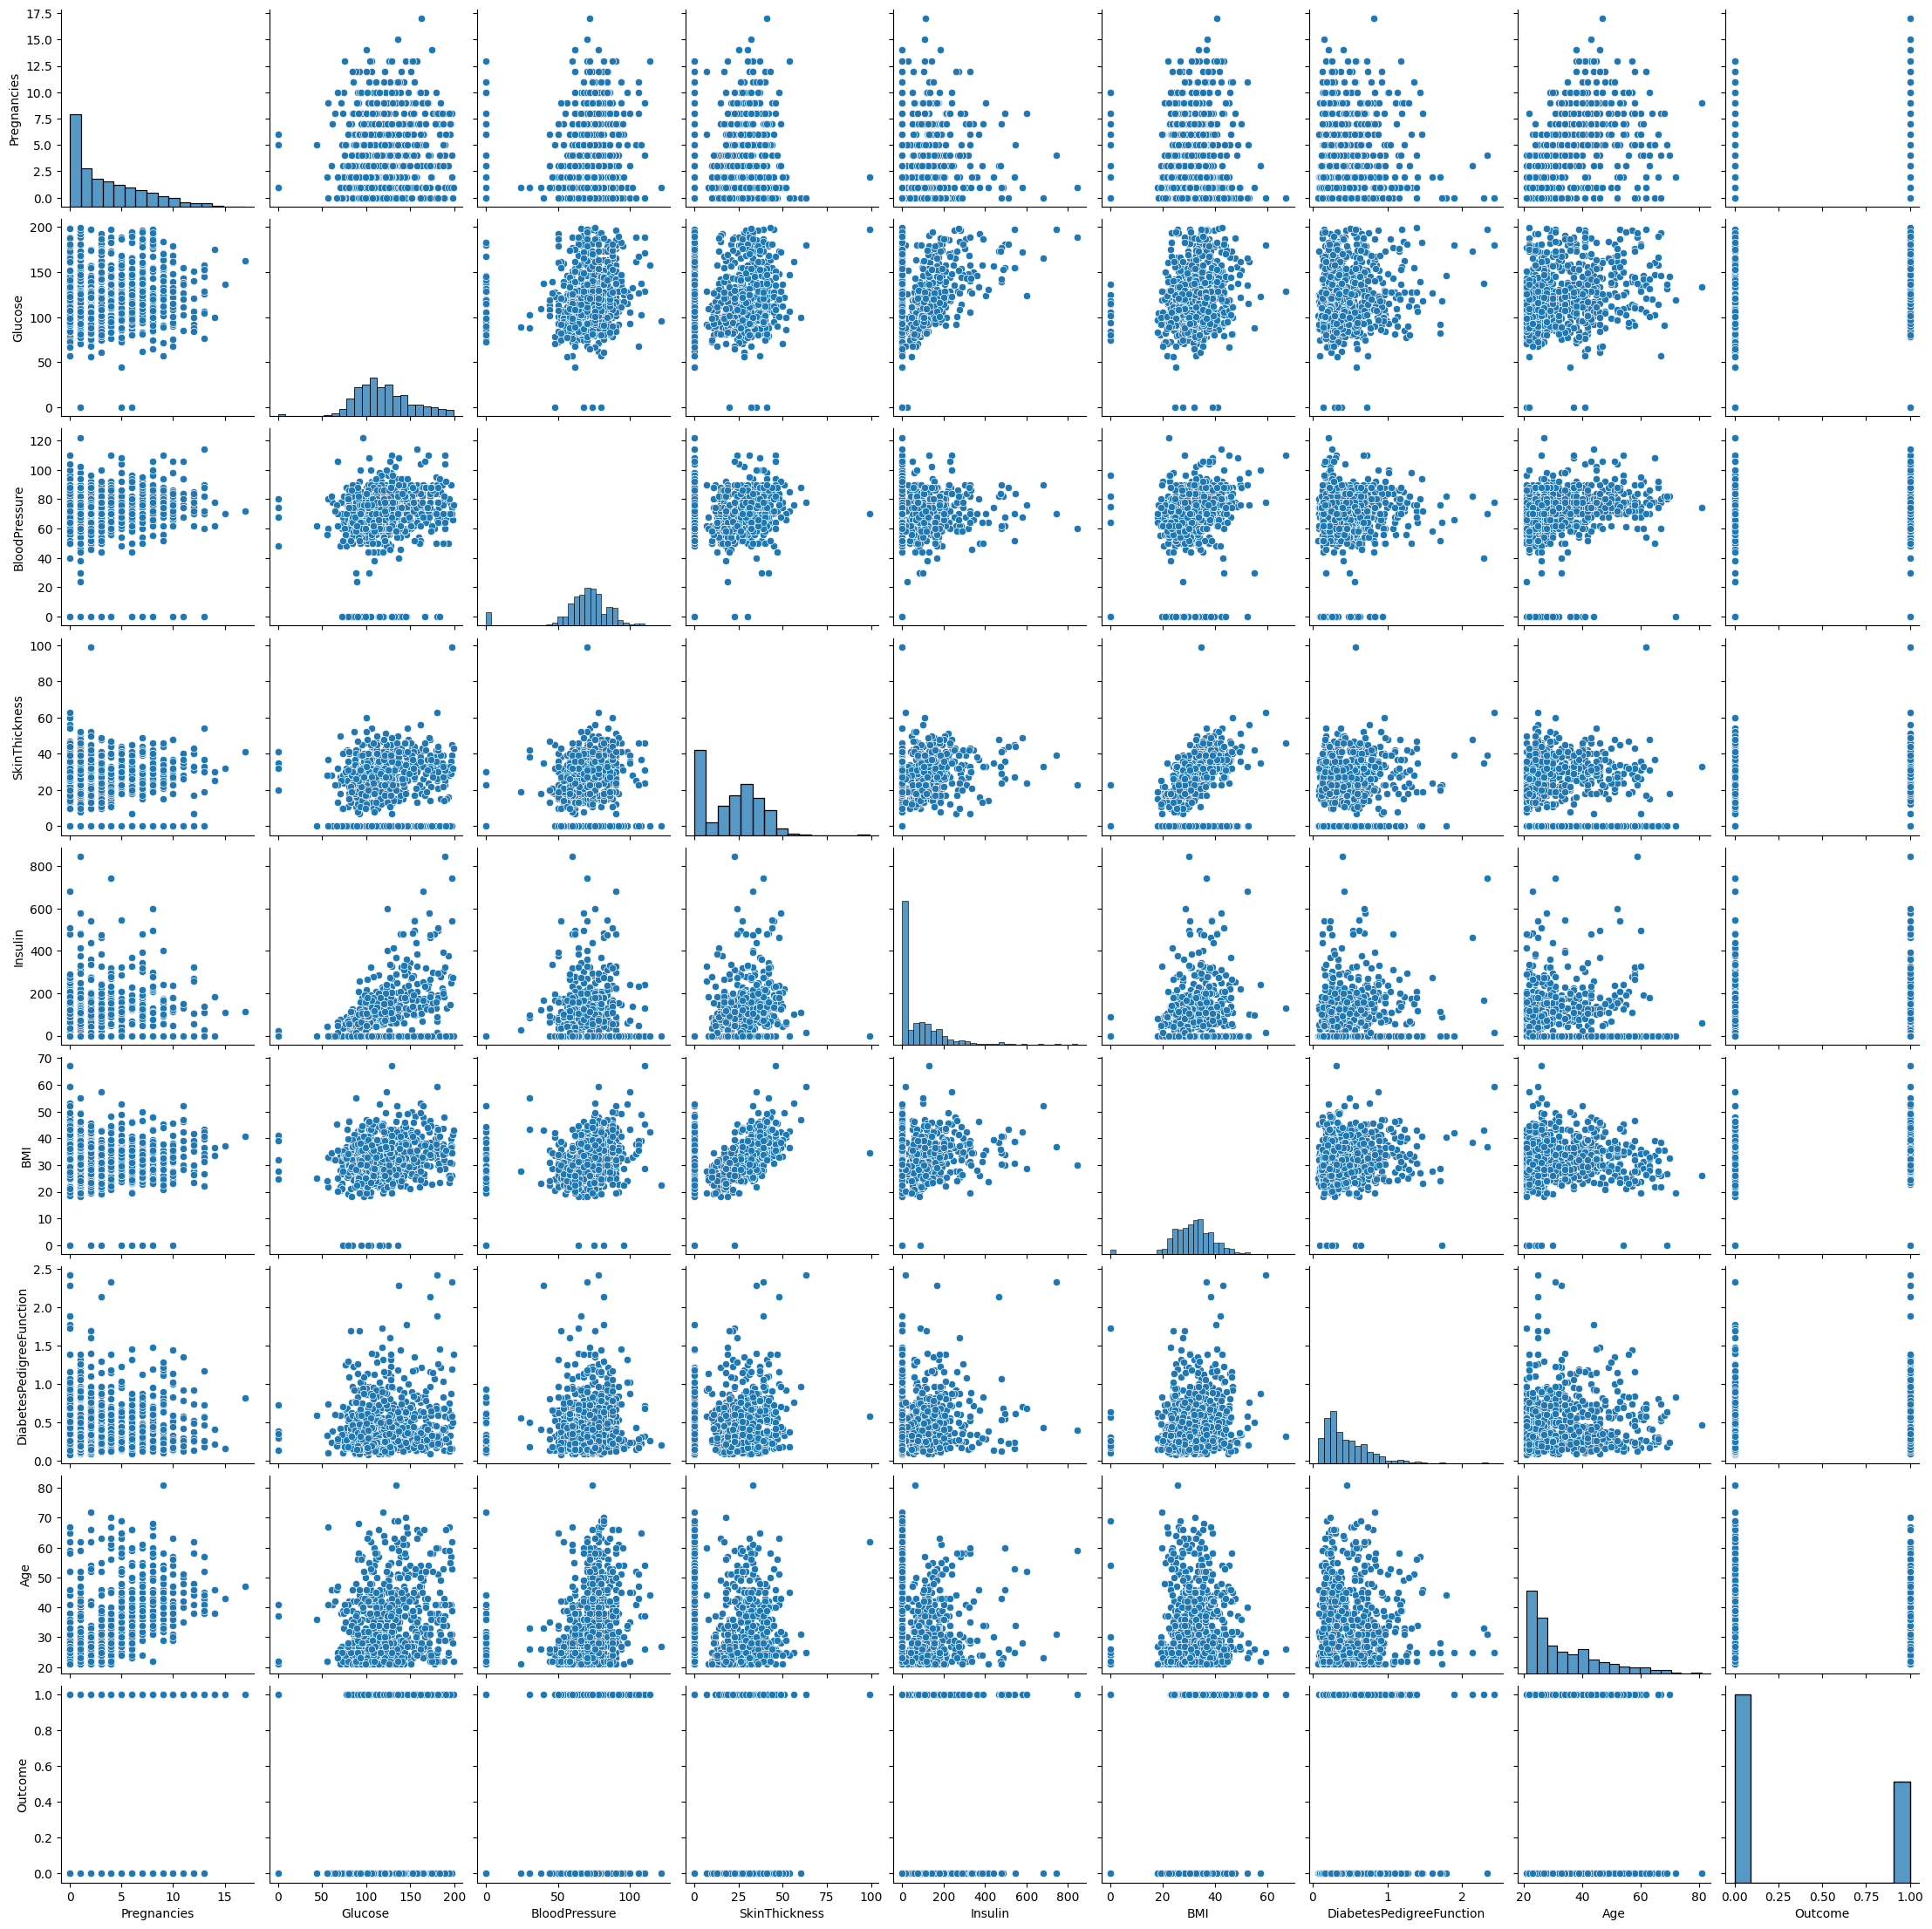

In [4]:
sns.pairplot(data)

Outcome
0    500
1    268
Name: count, dtype: int64 



<Axes: ylabel='count'>

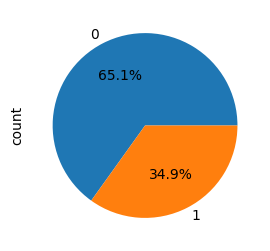

In [5]:
plt.figure(figsize=(4,3))

print(data["Outcome"].value_counts(), "\n")

data["Outcome"].value_counts().plot(kind="pie", autopct = "%1.1f%%")

Correlación entre variables: 



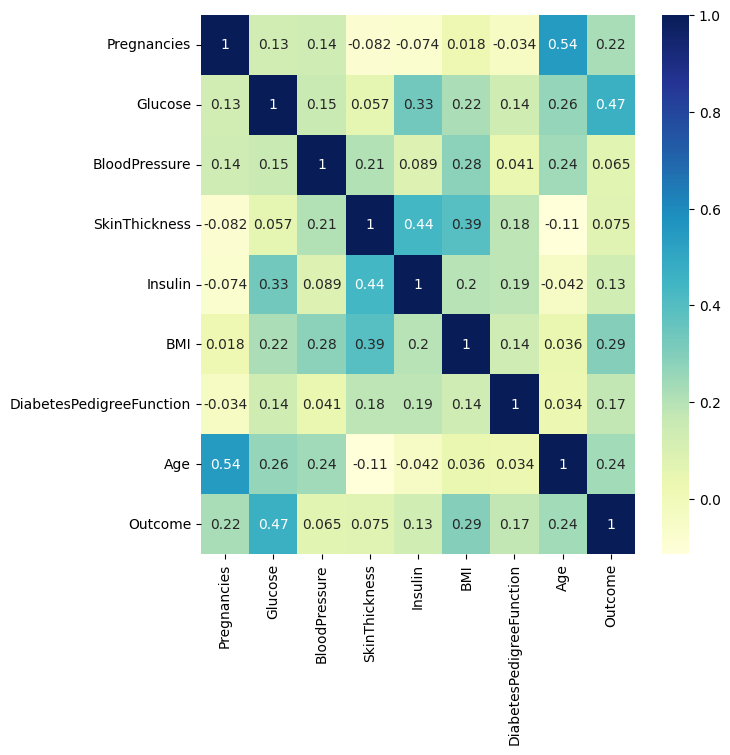

In [6]:
print("Correlación entre variables: \n")

plt.figure(figsize=(7,7))
sns.heatmap(data.corr(), annot = True, cmap = "YlGnBu") #Mapa de calor para mostrar la correlación entre variables
plt.show()


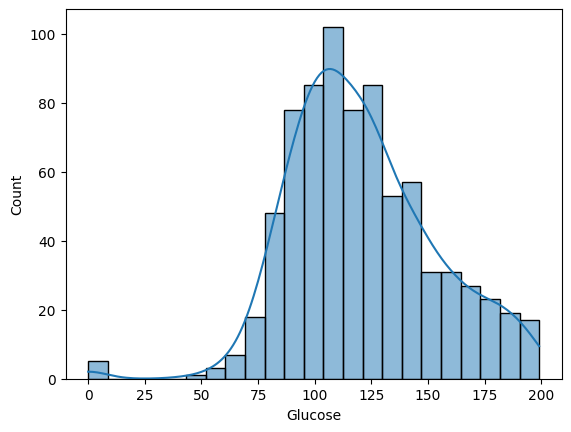

In [7]:
sns.histplot(data["Glucose"], kde = True)
plt.show()

In [8]:
df = data[data["Glucose"] >= 100]
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,571.000000,571.000000,571.000000,571.000000,571.000000,571.000000,571.000000,571.000000,571.000000
mean,4.066550,133.381786,70.656743,20.765324,94.017513,32.733625,0.484984,34.654991,0.441331
std,3.491712,25.868316,19.088102,16.742872,127.739495,7.767428,0.345766,12.179004,0.496981
min,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,112.000000,64.000000,0.000000,0.000000,27.850000,0.240000,25.000000,0.000000
50%,3.000000,127.000000,74.000000,23.000000,46.000000,32.800000,0.385000,31.000000,0.000000
75%,6.500000,149.500000,82.000000,33.000000,155.000000,37.200000,0.660000,42.000000,1.000000
max,17.000000,199.000000,114.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score

In [10]:
list = [x for x in data.columns if x != "Outcome"]
x = np.array(data[list])
y = np.array(data[["Outcome"]])

scaler = StandardScaler()
x = scaler.fit_transform(x)

#Y no se escala porque es la tiene la necesidad de escalar

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [11]:
svc = SVC( C = 0.1, kernel = "linear", class_weight = "balanced", gamma = 0.01)

svc.fit(x_train, y_train)

c:\Users\Juan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(C=0.1, class_weight='balanced', gamma=0.01, kernel='linear')

In [12]:
y_pred = svc.predict(x_test)

In [13]:
print("Classification Report: \n",classification_report(y_test, y_pred), "\n")
print("CM: \n", confusion_matrix(y_test, y_pred), "\n")

Classification Report: 
               precision    recall  f1-score   support

           0       0.82      0.69      0.75        99
           1       0.56      0.73      0.63        55

    accuracy                           0.70       154
   macro avg       0.69      0.71      0.69       154
weighted avg       0.73      0.70      0.71       154
 

CM: 
 [[68 31]
 [15 40]] 



Roc score: 
 0.7070707070707071 



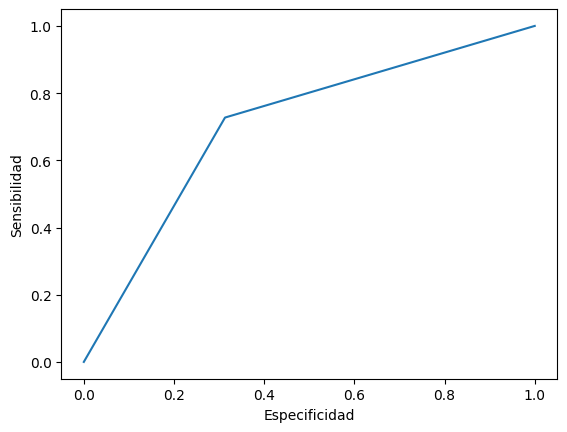

In [14]:
print("Roc score: \n", roc_auc_score(y_test, y_pred), "\n")

fpr, tpr, thresholds = roc_curve(y_test, y_pred)

plt.plot(fpr, tpr)
plt.xlabel("Especificidad")
plt.ylabel("Sensibilidad")
plt.show()

# Clasificación de imágenes #

In [15]:
from sklearn.datasets import fetch_lfw_people 

In [ ]:
faces =  fetch_lfw_people(min_faces_per_person = 10) 
print(faces.target_names)

['Aaron Peirsol' 'Abdoulaye Wade' 'Abdullah' 'Abdullah Gul'
 'Abdullah al-Attiyah' 'Abel Pacheco' 'Abid Hamid Mahmud Al-Tikriti'
 'Adam Sandler' 'Adel Al-Jubeir' 'Adolfo Aguilar Zinser' 'Adrien Brody'
 'Ahmed Chalabi' 'Ai Sugiyama' 'Aicha El Ouafi' 'Akbar Hashemi Rafsanjani'
 'Akhmed Zakayev' 'Al Gore' 'Al Pacino' 'Al Sharpton' 'Alan Greenspan'
 'Alastair Campbell' 'Albert Costa' 'Alec Baldwin' 'Alejandro Avila'
 'Alejandro Toledo' 'Aleksander Kwasniewski' 'Alex Sink'
 'Alexander Downer' 'Alexander Losyukov' 'Alexandra Stevenson'
 'Ali Khamenei' 'Ali Naimi' 'Allyson Felix' 'Alvaro Noboa'
 'Alvaro Silva Calderon' 'Alvaro Uribe' 'Amanda Bynes' 'Amelia Vega'
 'Amelie Mauresmo' 'Amer al-Saadi' 'Ana Guevara' 'Ana Palacio'
 'Anastasia Myskina' 'Anders Ebbeson' 'Anders Fogh Rasmussen'
 'Andre Agassi' 'Andrew Weissmann' 'Andy Roddick' 'Angela Bassett'
 'Angela Merkel' 'Angelina Jolie' 'Angelo Reyes' 'Anibal Ibarra'
 'Ann Veneman' 'Anna Kournikova' 'Anne Krueger' 'Anne McLellan'
 'Annette Lu' '

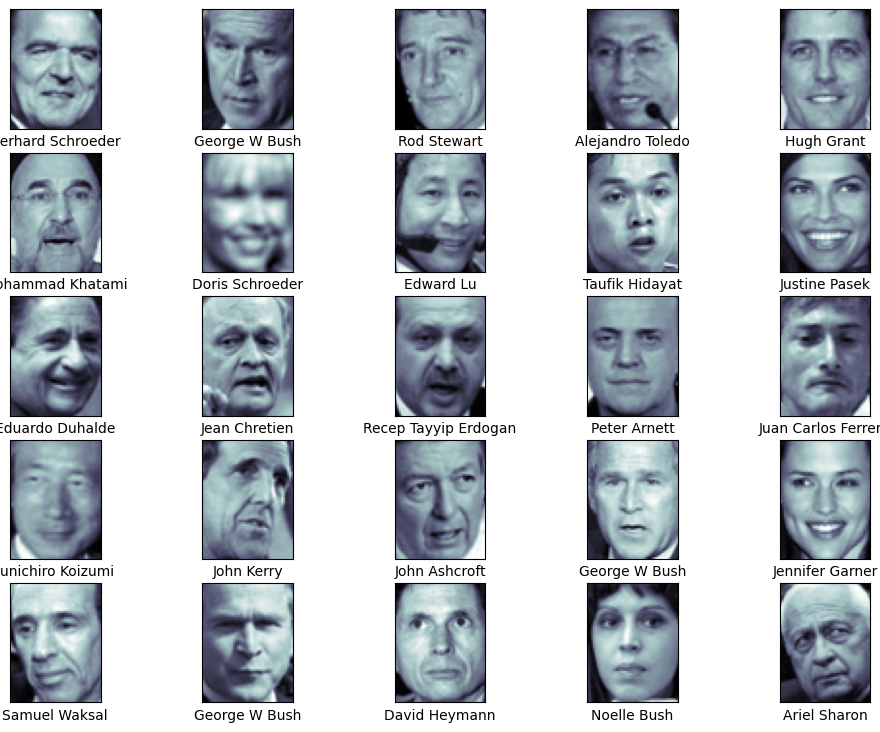

In [17]:
fig, ax = plt.subplots(5,5, figsize = (12,9))
for i, ax_i in enumerate(ax.flat):
    ax_i.imshow(faces.images[i], cmap = "bone")
    ax_i.set(xticks = [], yticks = [], xlabel = faces.target_names[faces.target[i]])

In [18]:
from sklearn.decomposition import PCA #¿Qué hace?
from sklearn.pipeline import make_pipeline #¿Qué hace?

In [19]:
pca = PCA(n_components=150, whiten = True, random_state = 42) 
scv = SVC(kernel = "rbf", class_weight= "balanced", C = 0.1, gamma = 0.01) #Clasificador SVC

model = make_pipeline(pca, scv) #hace el modelo, primero se hace PCA y luego SVC

In [20]:
x_train, x_test, y_train, y_test = train_test_split(faces.data, faces.target, test_size = 0.2, random_state = 42) #separa los datos

In [2]:
from sklearn.model_selection import GridSearchCV #Busca los mejores parámetros para el modelo mediante ciclos, midiendo la presición del modelo
param_grid = {
    "svc__C": [0.1, 1, 5,10], #Valores de C a probar
    "svc__gamma": [0.001, 0.005, 0.01, 0.05] #Valores de gamma a probar
}

In [1]:
grid = GridSearchCV(model, param_grid) #Crea el grid con los parámetros a probar

grid.fit(x_train, y_train) #Entrenando el modelo

NameError: name 'GridSearchCV' is not defined

In [ ]:
print(grid.best_params_, "\n") #Mejores parámetros encontrados

In [ ]:
clasificator = grid.best_estimator_ #Mejor estimador encontrado por el grid
y_pred = clasificator.predict(x_test) #Predicción con el mejor estimador

print(classification_report(y_test, y_pred, target_names= faces.target_names), "\n")